### multiple Linear Regression

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df =pd.read_csv("../../data/economic_index.csv", index_col=0)
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


**Drop the unnessary columns**

In [18]:
df.drop(["year", "month"], axis=1,inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


**Check missing values**

In [20]:
df.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

**Visualize the data**

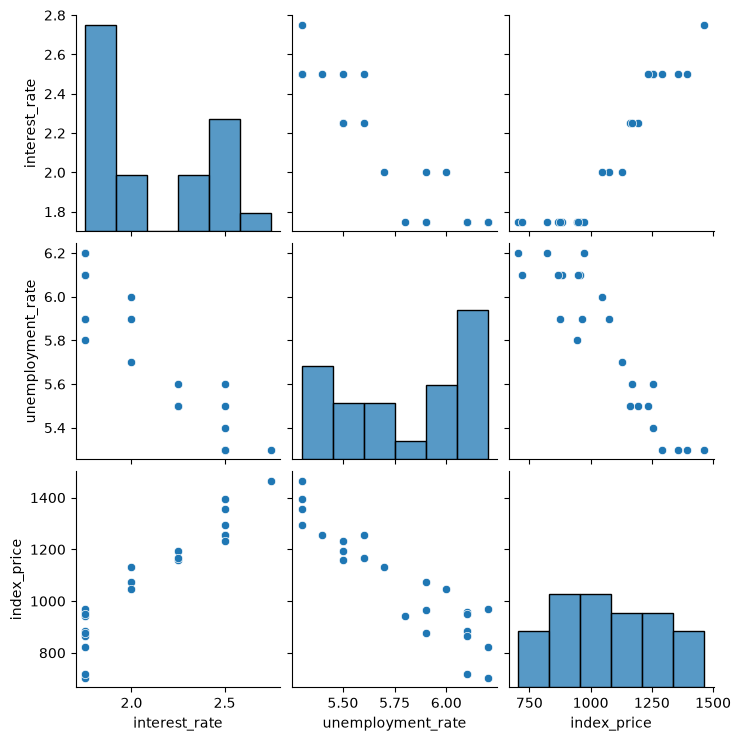

In [21]:
sns.pairplot(df)

**Check linear realtionship**

In [22]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


**visualize the data point more closely**

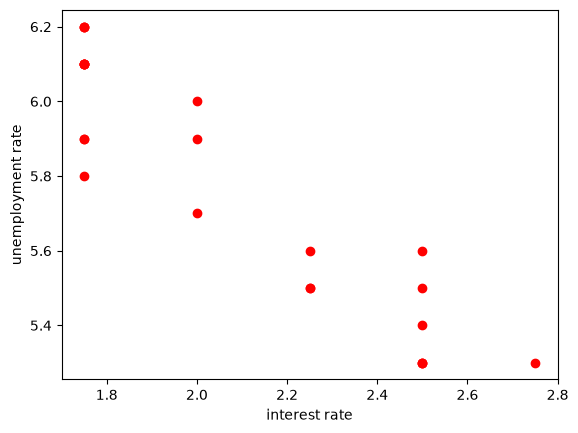

In [27]:
plt.scatter(df["interest_rate"], df["unemployment_rate"], color='r')
plt.xlabel("interest rate")
plt.ylabel("unemployment rate");

**divide into independet and dependent**

In [30]:
X = df.iloc[:, 0:-1]
y = df.iloc[:,-1]

**Split the data train test split**

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.25,
                                                    random_state=42)

**Regression plot**

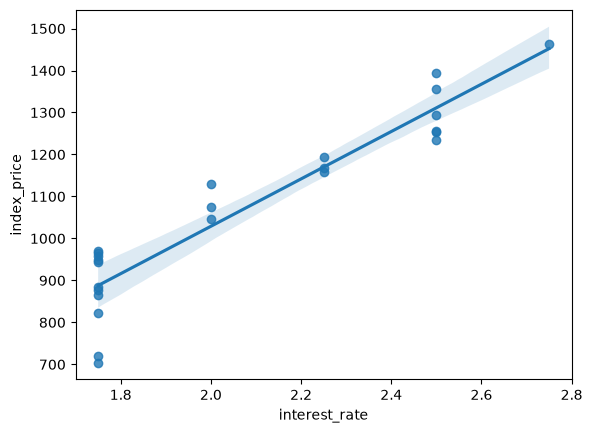

In [36]:
sns.regplot(x=df['interest_rate'], y=df['index_price']);

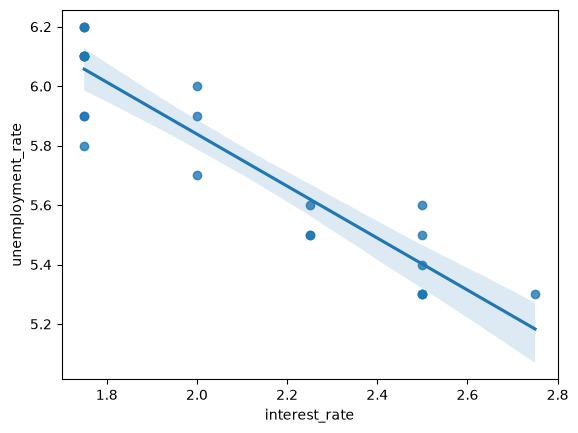

In [37]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate']);

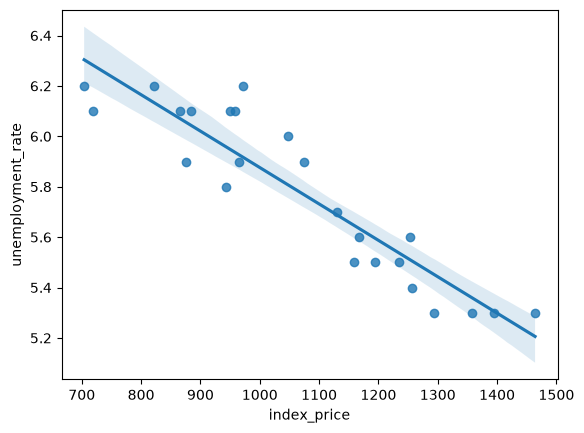

In [38]:
sns.regplot(x=df['index_price'], y=df['unemployment_rate']);

**Standarization**

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**train the model**

In [43]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 88.27,-116.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


**cross validation**

In [47]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(model, X_train, y_train, scoring = 'neg_mean_squared_error', cv=3)
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [49]:
print(validation_score.mean())

-5914.828180162396


In [64]:
print(f"intercept: {model.intercept_}")
print(f"coefficient: {model.coef_}")

intercept: 1053.4444444444443
coefficient: [  88.27275507 -116.25716066]


**Predication**

In [50]:
y_pred = model.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

**Performance metrics**

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MSE: 5793.762887712583
MAE: 59.93578152323558
RMSE: 76.11677139574815


In [52]:
from sklearn.metrics import r2_score
score= r2_score(y_test, y_pred)
score

0.8278978091457141

In [53]:
# Adjusted R2
n = X_test.shape[0] 
p = X_test.shape[1]   
adjusted_r2 = 1 - ((1 - score) * (n - 1) / (n - p - 1))
adjusted_r2

0.7131630152428567

**Assumptions**

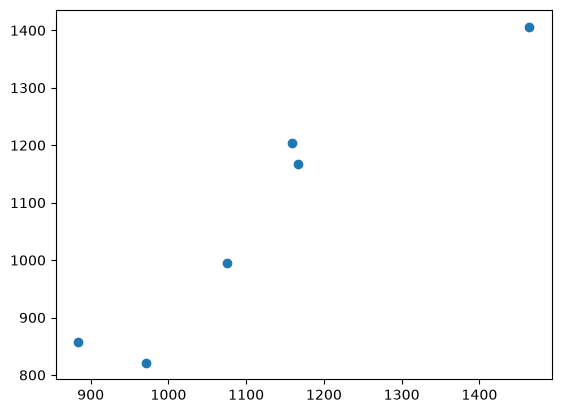

In [56]:
plt.scatter(y_test, y_pred);

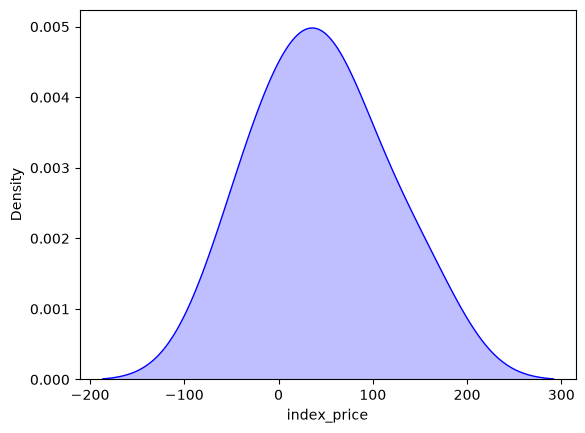

In [58]:
residuals = y_test - y_pred
sns.kdeplot(residuals, fill=True, color='blue');

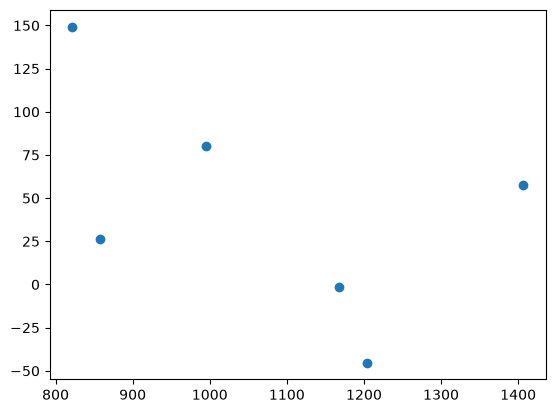

In [60]:
# scatterplot with respect to predication and residuals
plt.scatter(y_pred, residuals);

**Ols Method**

In [61]:
import statsmodels.api as sm
ols_model = sm.OLS(y_train, X_train).fit()

In [62]:
pred = ols_model.predict(X_test)
pred

array([ 150.78325954, -231.79392541,  353.06855924, -195.73554836,
        -58.53452146,  114.72488249])

In [63]:
print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 23 Sep 2026   Prob (F-statistic):                       0.754
Time:                        09:06:02   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------